# AI Model for Detecting Cancer-Related DNA Mutations

## Project Objective
This project builds a deep learning model that predicts whether a DNA mutation is associated with cancer.

The model learns patterns in DNA sequences using a **Convolutional Neural Network (CNN)**.

---

## Workflow

1. Create DNA mutation dataset
2. Explore dataset statistics
3. Encode DNA sequences using one-hot encoding
4. Train a CNN model
5. Evaluate model performance
6. Visualize results

---

## DNA Encoding

DNA nucleotides are converted into vectors:

| Base | Encoding |
|-----|-----|
| A | [1,0,0,0] |
| T | [0,1,0,0] |
| G | [0,0,1,0] |
| C | [0,0,0,1] |

---

## Model Architecture

CNN Layers used:

Input DNA Sequence  
↓  
Conv1D Layer  
↓  
MaxPooling  
↓  
Flatten  
↓  
Dense Layers  
↓  
Cancer Mutation Prediction

---

## Technologies Used

- Python
- Pandas
- NumPy
- TensorFlow
- Scikit-learn
- Matplotlib
- Seaborn

Dataset Preview
   Sequence  Label
0  ATGCGTAC      1
1  ATTTGCCA      0
2  CGTAGCTA      1
3  GGCATGCA      1
4  ATGCGTAA      1

Dataset Info
           Label
count  15.000000
mean    0.600000
std     0.507093
min     0.000000
25%     0.000000
50%     1.000000
75%     1.000000
max     1.000000


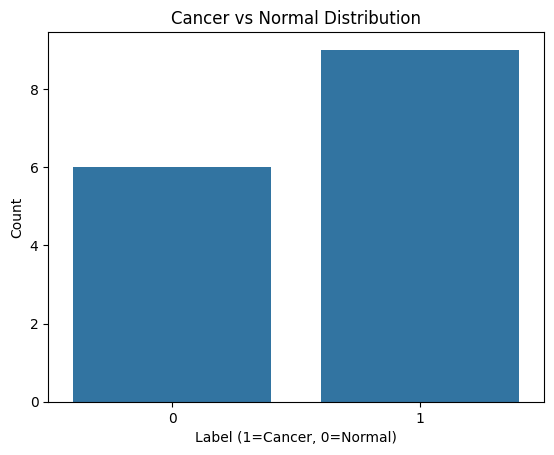

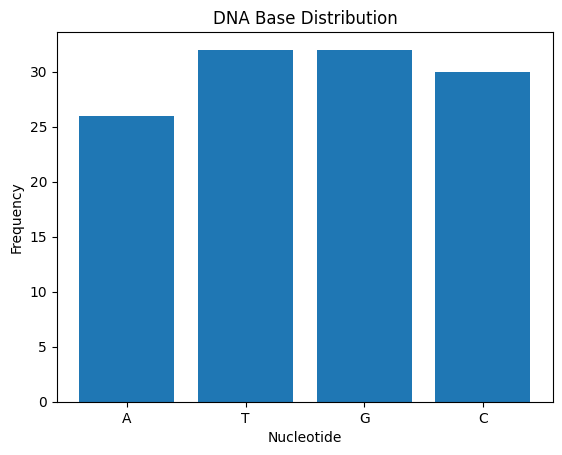


Train Shape: (10, 8, 4)
Test Shape: (5, 8, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 6, 32)          │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,689 (26.13 KB)

 Trainable params: 6,689 (26.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.5000 - loss: 0.6986 - val_accuracy: 0.6000 - val_loss: 0.6423
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6444 - loss: 0.6036 - val_accuracy: 0.6000 - val_loss: 0.6332
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5042 - loss: 0.6886 - val_accuracy: 0.6000 - val_loss: 0.6304
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5875 - loss: 0.6228 - val_accuracy: 0.6000 - val_loss: 0.6267
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7681 - loss: 0.5587 - val_accuracy: 0.6000 - val_loss: 0.6212
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.5861 - loss: 0.6552 - val_accuracy: 0.6000 - val_loss: 0.6169
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9125 - loss: 0.5166 - val_accuracy: 0.6000 - val_loss: 0.6124
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8639 - loss: 0.5125 - val_accuracy: 0.6000 - val_loss: 0.608

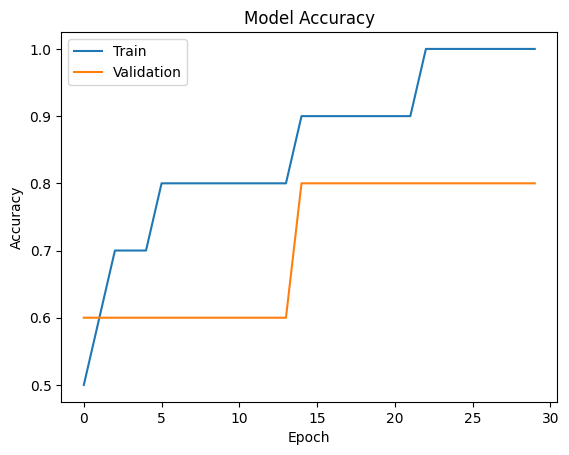

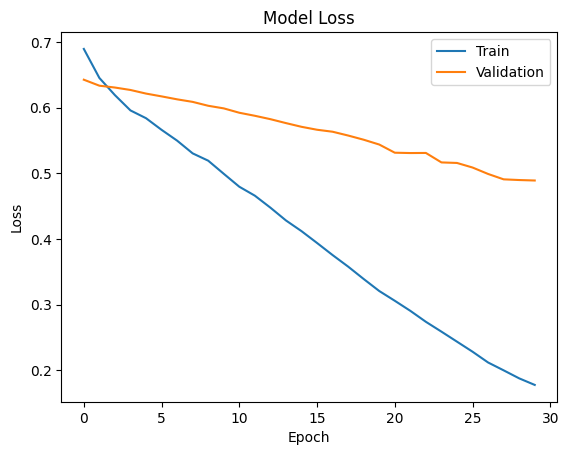

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


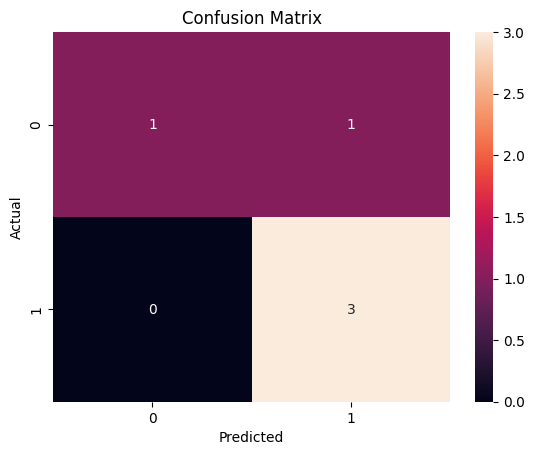


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


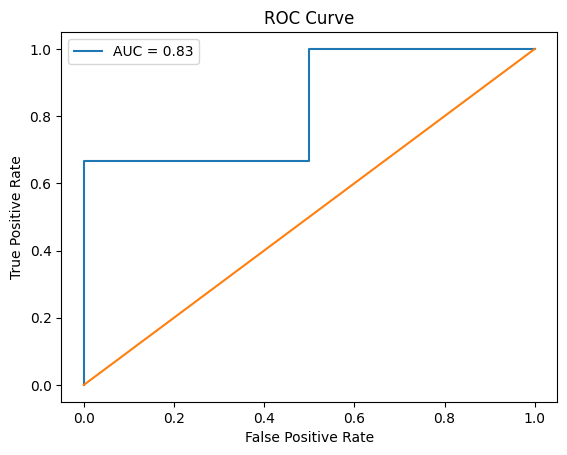

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step

Cancer Mutation Probability: 0.6591229


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

# -------------------------
# Create Dataset
# -------------------------

data = pd.DataFrame({
    "Sequence":[
        "ATGCGTAC","ATTTGCCA","CGTAGCTA","GGCATGCA","ATGCGTAA",
        "CGTACGTA","TTGCGTAC","ATGCCGTA","GGGCGTAC","ATGTTTAC",
        "CGGCGTAC","ATGCGCCC","TTTCGTAC","ATGCGGAC","CGTAGTTA"
    ],

    "Label":[
        1,0,1,1,1,
        0,0,1,1,0,
        1,1,0,1,0
    ]
})

print("Dataset Preview")
print(data.head())

# -------------------------
# Dataset Statistics
# -------------------------

print("\nDataset Info")
print(data.describe())

# -------------------------
# Label Distribution Plot
# -------------------------

plt.figure()
sns.countplot(x=data["Label"])
plt.title("Cancer vs Normal Distribution")
plt.xlabel("Label (1=Cancer, 0=Normal)")
plt.ylabel("Count")
plt.show()

# -------------------------
# DNA Base Distribution
# -------------------------

all_seq = "".join(data["Sequence"])
bases = ["A","T","G","C"]
counts = [all_seq.count(b) for b in bases]

plt.figure()
plt.bar(bases,counts)
plt.title("DNA Base Distribution")
plt.xlabel("Nucleotide")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# DNA Encoding
# -------------------------

mapping = {
"A":[1,0,0,0],
"T":[0,1,0,0],
"G":[0,0,1,0],
"C":[0,0,0,1]
}

def encode_seq(seq):
    return np.array([mapping[x] for x in seq])

X = np.array([encode_seq(seq) for seq in data["Sequence"]])
y = data["Label"].values

# -------------------------
# Train Test Split
# -------------------------

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

print("\nTrain Shape:",X_train.shape)
print("Test Shape:",X_test.shape)

# -------------------------
# Build CNN Model
# -------------------------

model = Sequential()

model.add(Conv1D(32,3,activation='relu',input_shape=(8,4)))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

model.summary()

# -------------------------
# Train Model
# -------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=2,
    validation_data=(X_test,y_test),
    verbose=1
)

# -------------------------
# Accuracy Plot
# -------------------------

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# -------------------------
# Loss Plot
# -------------------------

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# -------------------------
# Predictions
# -------------------------

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

# -------------------------
# Confusion Matrix
# -------------------------

cm = confusion_matrix(y_test,y_pred)

plt.figure()
sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report")
print(classification_report(y_test,y_pred))

# -------------------------
# ROC Curve
# -------------------------

y_prob = model.predict(X_test)

fpr,tpr,thresholds = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr,label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# -------------------------
# Test New DNA Sequence
# -------------------------

test_seq = encode_seq("ATGCGTAC")
test_seq = test_seq.reshape(1,8,4)

prediction = model.predict(test_seq)

print("\nCancer Mutation Probability:",prediction[0][0])